In [21]:
# Smart Support Ticket Classification & Priority Prediction
#This notebook demonstrates the complete workflow of building an NLP-based machine learning system to classify support tickets and predict their priority.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import sys
import os

# Add project root to path
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath('__file__'))))

from src.preprocessing import preprocess_dataframe
from src.feature_engineering import create_tfidf_vectorizer, create_bow_vectorizer
from src.evaluate import evaluate_model

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [27]:
## 1. Exploratory Data Analysis (EDA)

In [28]:
# Load dataset
df = pd.read_csv('../dataset/support_tickets.csv')
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (10000, 3)


,ticket_text,category,priority
0,"Hi support, My billing address needs to be upd...",Billing,Medium
1,"Hi support, Is there a fee for using a specifi...",Payment,Low
2,How do I change my payment method for future b...,Billing,Low
3,"Hello, I was promised a refund 3 weeks ago and...",Refund,High
4,There is an unauthorized charge on my bill. I ...,Billing,High


In [29]:
# Missing values and duplicates
print("Missing Values:\n", df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

Missing Values:
 ticket_text    0
category       0
priority       0
dtype: int64

Duplicate Rows: 8206


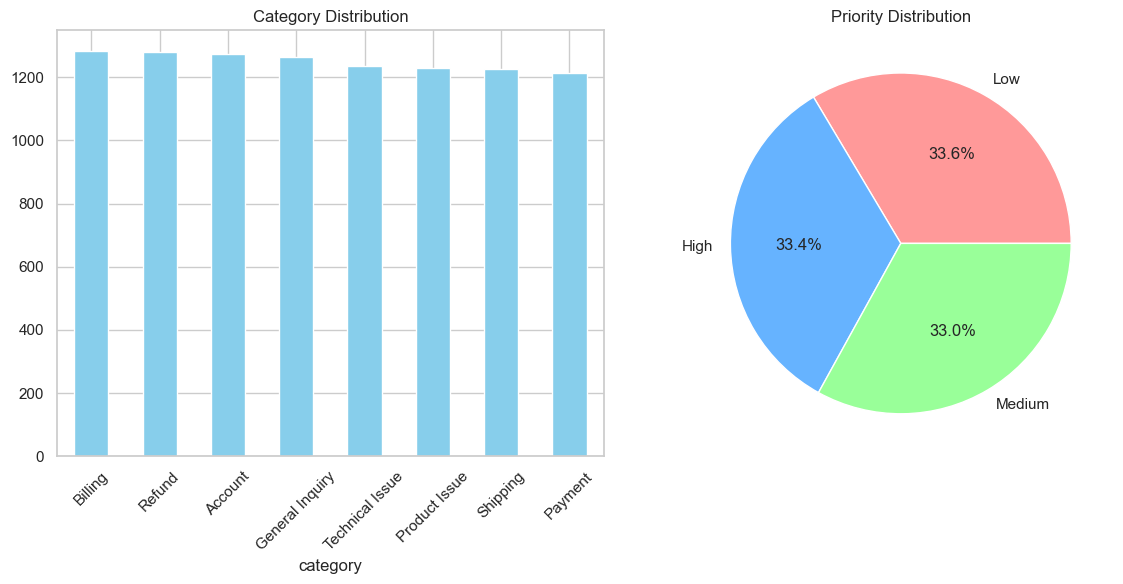

In [30]:
# Class distribution
plt.subplot(1, 2, 1)
df['category'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Category Distribution')
plt.xticks(rotation=45)

# Priority distribution
plt.subplot(1, 2, 2)
df['priority'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
plt.title('Priority Distribution')
plt.ylabel('')
plt.tight_layout()
plt.show()

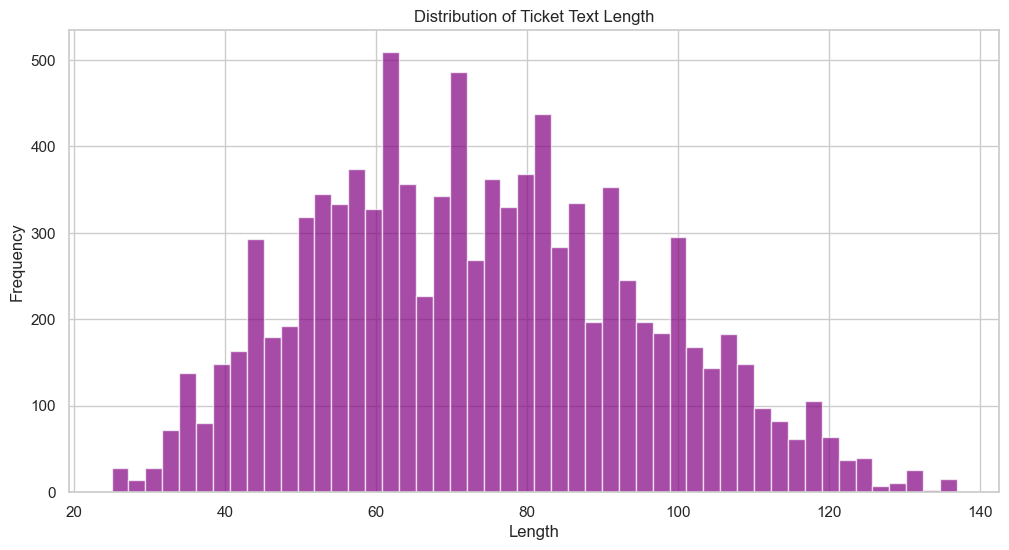

Average Ticket Length: 73.88 characters


In [31]:
# Ticket length analysis
df['text_length'] = df['ticket_text'].apply(len)
plt.hist(df['text_length'], bins=50, color='purple', alpha=0.7)
plt.title('Distribution of Ticket Text Length')
plt.xlabel('Length')
plt.ylabel('Frequency')
plt.show()
print(f"Average Ticket Length: {df['text_length'].mean():.2f} characters")

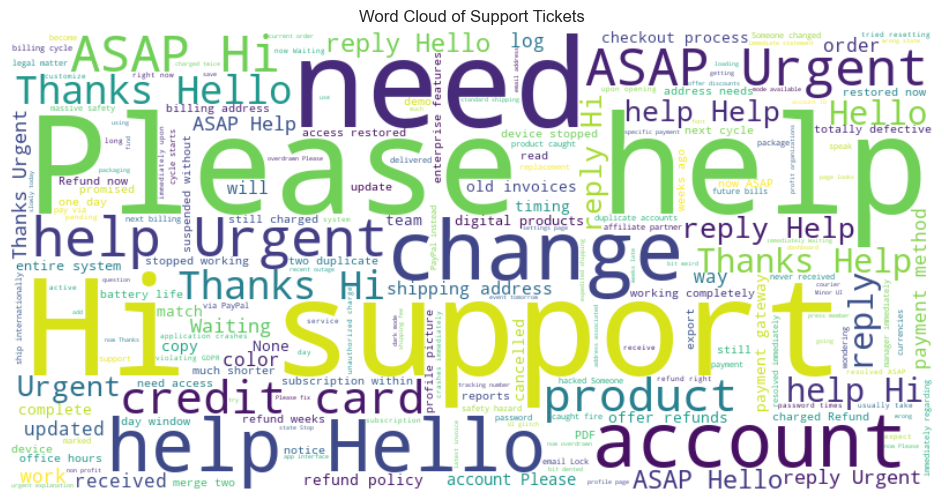

In [8]:
# Word Cloud
text = ' '.join(df['ticket_text'])
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Support Tickets')
plt.show()

In [9]:
## 2. Text Preprocessing

In [10]:
# Apply preprocessing
df_clean = preprocess_dataframe(df, 'ticket_text')
df_clean[['ticket_text', 'cleaned_text']].head()

,ticket_text,cleaned_text
0,"Hi support, My billing address needs to be upd...",hi support billing address need updated next c...
1,"Hi support, Is there a fee for using a specifi...",hi support fee using specific payment method t...
2,How do I change my payment method for future b...,change payment method future bill waiting reply
3,"Hello, I was promised a refund 3 weeks ago and...",hello promised refund week ago still received ...
4,There is an unauthorized charge on my bill. I ...,unauthorized charge bill need resolved soon po...


In [11]:
## 3. Feature Engineering

In [12]:
# TF-IDF
X_tfidf, tfidf_vec = create_tfidf_vectorizer(df_clean['cleaned_text'])
print(f"TF-IDF Shape: {X_tfidf.shape}")

# Bag of Words
X_bow, bow_vec = create_bow_vectorizer(df_clean['cleaned_text'])
print(f"BoW Shape: {X_bow.shape}")

TF-IDF Shape: (10000, 1074)
BoW Shape: (10000, 1074)


In [13]:
## 4. Model Training & Evaluation
#We will train models for Category prediction using TF-IDF.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

y_cat = df_clean['category']
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y_cat, test_size=0.2, random_state=42, stratify=y_cat)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
evaluate_model(model, X_test, y_test, 'Logistic Regression (Category)')

Accuracy: 1.0000


{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

In [15]:
## 5. Priority Prediction

In [16]:
y_pri = df_clean['priority']
X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(X_tfidf, y_pri, test_size=0.2, random_state=42, stratify=y_pri)

model_p = LogisticRegression(max_iter=1000, class_weight='balanced')
model_p.fit(X_train_p, y_train_p)
y_pred_p = model_p.predict(X_test_p)

print(f"Priority Accuracy: {accuracy_score(y_test_p, y_pred_p):.4f}")
evaluate_model(model_p, X_test_p, y_test_p, 'Logistic Regression (Priority)')

Priority Accuracy: 1.0000


{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

In [17]:
## 6. Prediction on New Data

In [18]:
from src.predict import predict_ticket

test_ticket = "My payment was deducted twice. Please refund me ASAP!"
result = predict_ticket(test_ticket)

print(f"Ticket: {test_ticket}")
print(f"Predicted Category: {result['category']} ({result['category_confidence']:.1f}%)")
print(f"Predicted Priority: {result['priority']} ({result['priority_confidence']:.1f}%)")

Ticket: My payment was deducted twice. Please refund me ASAP!
Predicted Category: Refund (23.8%)
Predicted Priority: High (40.7%)


In [19]:
## 7. Conclusions
#- TF-IDF with n-grams provides excellent feature representation for ticket classification.
#- Logistic Regression performs robustly for both category and priority prediction.
#- The system successfully automates ticket routing and prioritization, saving significant manual effort.